Libraries

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import time
import random
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

Data Preprocessing and Agumentation

In [3]:
train_trans=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(224,scale=(0.80,1.0)),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.ToTensor()
])
test_trans=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [4]:
Train_dataset=datasets.ImageFolder("/content/drive/MyDrive/classification_object/train",transform=train_trans)
Test_dataset=datasets.ImageFolder("/content/drive/MyDrive/classification_object/test",transform=test_trans)
valid_dataset=datasets.ImageFolder("/content/drive/MyDrive/classification_object/valid",transform=test_trans)

train_loader=DataLoader(Train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(Test_dataset,batch_size=32,shuffle=False)
valid_loader=DataLoader(valid_dataset,batch_size=32,shuffle=False)

Data Understanding

In [5]:
def count_images(x):
  count=[0]*len(x.classes)
  for path,label in x.samples:
    count[label]=count[label]+1
  return dict(zip(x.classes,count))

In [6]:
print("Train dataset",len(Train_dataset))
print("Train classes count: \n",count_images(Train_dataset))
print("")
print("Test dataset",len(Test_dataset))
print("Test classes count: \n",count_images(Test_dataset))
print("")
print("Validation dataset",len(valid_dataset))
print("Tvalidation classes count: \n",count_images(valid_dataset))

Train dataset 2662
Train classes count: 
 {'bird': 1414, 'drone': 1248}

Test dataset 215
Test classes count: 
 {'bird': 121, 'drone': 94}

Validation dataset 442
Tvalidation classes count: 
 {'bird': 217, 'drone': 225}


 IMAGE VISUALIZATION

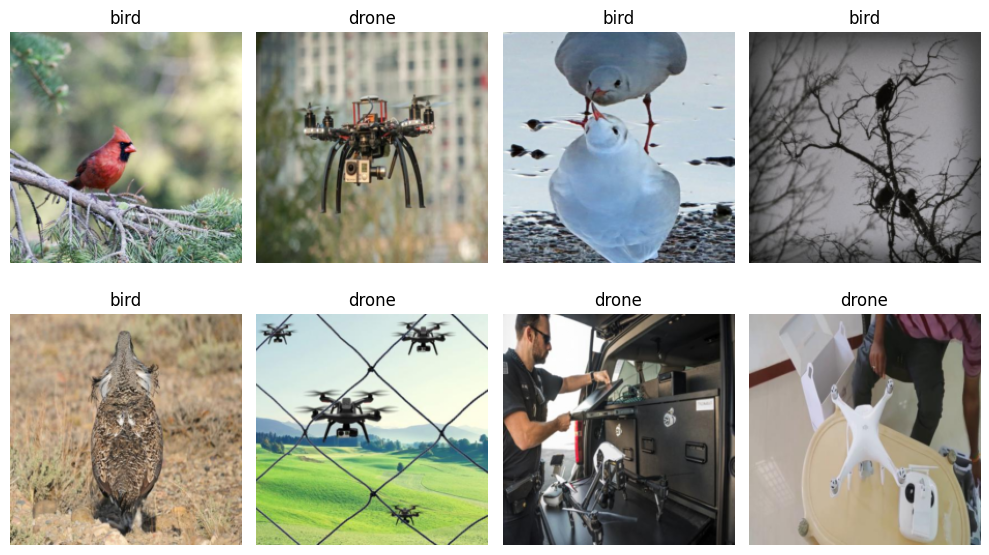

In [27]:
preview_data=datasets.ImageFolder("/content/drive/MyDrive/classification_object/train",transform=test_trans)

plt.figure(figsize=(10,6))

for i in range(8):
  img,label=preview_data[random.randint(0,len(preview_data)-1)]
  img=img.permute(1,2,0)
  plt.subplot(2,4,i+1)
  plt.imshow(img)
  plt.title(preview_data.classes[label])
  plt.axis('off')
plt.tight_layout()
plt.show()




CHECK GPU IS AVAILABLE

In [28]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


 CUSTOM CNN MODEL

In [29]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv=nn.Sequential(
        nn.Conv2d(3,16,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(16,32,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),
    )
    self.fc=nn.Sequential(
        nn.Linear(32*56*56,128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128,1)
    )
  def forward(self,x):
    conv=self.conv(x)
    flat=conv.view(conv.size(0),-1)
    fc=self.fc(flat)
    return fc

TRAINING SETUP

In [30]:
model=CNN().to(device)
criterion=nn.BCEWithLogitsLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

TRAINING AND VALIDATION

In [31]:
counter=0
patience=6
checkpoint="CNN_model.pth"
best_valid_loss=float("inf")

epochs=5
c_train_losses=[]
c_valid_losses=[]
c_valid_accuracy=[]

start_time=time.time()

for epoch in range(epochs):
  model.train()
  running_loss=0
  for images,labels in train_loader:
    optimizer.zero_grad()
    images=images.to(device)
    labels=labels.unsqueeze(1).float().to(device)
    pred_labels=model(images)
    loss=criterion(pred_labels,labels)
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
  c_train_losses.append(running_loss/len(train_loader))
  print(f"Epoch{epoch}/{epochs}:{running_loss/len(train_loader)}")

  model.eval()
  y_pred=[]
  y_label=[]
  valid_loss=0.0

  with torch.no_grad():
    for images,labels in valid_loader:
      images=images.to(device)
      labels=labels.unsqueeze(1).float().to(device)
      pred_labels=model(images)
      pred=torch.round(torch.sigmoid(pred_labels))
      loss=criterion(pred_labels,labels)
      valid_loss+=loss.item()
      y_pred.extend(pred.tolist())
      y_label.extend(labels.tolist())
    c_valid_losses.append(valid_loss/len(valid_loader))
  y_pred=[int(x[0]) for x in y_pred]
  y_label=[int(x[0]) for x in y_label]

  accuracy=accuracy_score(y_label,y_pred)
  confusion=confusion_matrix(y_label,y_pred)
  classification=classification_report(y_label,y_pred)
  c_valid_losses.append(accuracy)

  print(f"Accuracy: {accuracy}")
  print(f"Validation loss: {c_valid_losses}")
  print(f"Confusion Matrix:\n {confusion}")
  print(f"Classification Report:\n {classification}")


  if valid_loss<best_valid_loss:
    best_valid_loss=valid_loss
    counter=0
    torch.save(model.state_dict(),checkpoint)
  else:
    counter+=1
    if counter>=patience:
      print("Early stopping")
      break

end_time=time.time()
print(f"Training Time: {(end_time-start_time)/60}")

Epoch0/5:0.6657846974475043
Accuracy: 0.6809954751131222
Validation loss: [0.5677637670721326, 0.6809954751131222]
Confusion Matrix:
 [[192  25]
 [116 109]]
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.88      0.73       217
           1       0.81      0.48      0.61       225

    accuracy                           0.68       442
   macro avg       0.72      0.68      0.67       442
weighted avg       0.72      0.68      0.67       442

Epoch1/5:0.6002868020108768
Accuracy: 0.5882352941176471
Validation loss: [0.5677637670721326, 0.6809954751131222, 0.7009876711027963, 0.5882352941176471]
Confusion Matrix:
 [[ 42 175]
 [  7 218]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.19      0.32       217
           1       0.55      0.97      0.71       225

    accuracy                           0.59       442
   macro avg       0.71      0.58      0.51       442

EVALUATION

In [32]:
model.eval()
y_preds=[]
y_labels=[]

with torch.no_grad():
  for images,labels in test_loader:
    images=images.to(device)
    labels=labels.unsqueeze(1).float().to(device)
    pred_labels=model(images)
    pred=torch.round(torch.sigmoid(pred_labels))
    y_preds.extend(pred.cpu().tolist())
    y_labels.extend(labels.tolist())

y_preds=[int(x[0]) for x in y_preds]
y_labels=[int(x[0]) for x in y_labels]

accuracy=accuracy_score(y_labels,y_preds)
confusion=confusion_matrix(y_labels,y_preds)
classification=classification_report(y_labels,y_preds)

print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n {confusion}")
print(f"Classification Report:\n {classification}")

Accuracy: 0.8046511627906977
Confusion Matrix:
 [[109  12]
 [ 30  64]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.90      0.84       121
           1       0.84      0.68      0.75        94

    accuracy                           0.80       215
   macro avg       0.81      0.79      0.80       215
weighted avg       0.81      0.80      0.80       215



TRANSFER LEARNING--->RESNET,MOBILENET,EFFICIENTNET

In [33]:
import torchvision.models as models

### predifined model for resnet50
def resnet50():
  model=models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
  model.fc=nn.Linear(model.fc.in_features,1)

  for name,param in model.named_parameters():
    if "Layer4" in name:
      param.requireds_grad=True
    else:
      param.requireds_grad=False
  return model

### predifined model for mobilenetv2
def mobilenet_v2():
  model=models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
  model.classifier[1]=nn.Linear(model.last_channel,1)

  for name,param in model.named_parameters():
    if "features.17" in name:
      param.requireds_grad=True
    else:
      param.requireds_grad=False
  return model

### predefined model for efficientnetb0
def efficientnet_b0():
  model=models.efficientnet_b0(pretrained=True)
  model.classifier[1]=nn.Linear(model.classifier[1].in_features,1)

  for name,param in model.named_parameters():
    if "features.6" in name:
      param.requireds_grad=True
    else:
      param.requireds_grad=False
  return model


RESNET50

TRAINING SETUP

In [41]:
resnet=resnet50().to(device)
criterion=nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(filter(lambda x:x.requires_grad,resnet.parameters()),lr=0.001)

TRAINING AND VALIDATION

In [42]:
counter=0
patience=6
checkpoint="RESNET_model.pth"
best_valid_loss=float("inf")

epochs=5
r_train_losses=[]
r_valid_losses=[]
r_valid_accuracy=[]

start_time=time.time()

for epoch in range(epochs):
  resnet.train()
  running_loss=0
  for images,labels in train_loader:
    optimizer.zero_grad()
    images=images.to(device)
    labels=labels.unsqueeze(1).float().to(device)
    pred_labels=resnet(images)
    loss=criterion(pred_labels,labels)
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
  r_train_losses.append(running_loss/len(train_loader))
  print(f"Epoch{epoch}/{epochs}:{running_loss/len(train_loader)}")

  resnet.eval()
  y_pred=[]
  y_label=[]
  valid_loss=0.0

  with torch.no_grad():
    for images,labels in valid_loader:
      images=images.to(device)
      labels=labels.unsqueeze(1).float().to(device)
      pred_labels=resnet(images)
      pred=torch.round(torch.sigmoid(pred_labels))
      loss=criterion(pred_labels,labels)
      valid_loss+=loss.item()
      y_pred.extend(pred.tolist())
      y_label.extend(labels.tolist())
    r_valid_losses.append(valid_loss/len(valid_loader))
  y_pred=[int(x[0]) for x in y_pred]
  y_label=[int(x[0]) for x in y_label]

  accuracy=accuracy_score(y_label,y_pred)
  confusion=confusion_matrix(y_label,y_pred)
  classification=classification_report(y_label,y_pred)
  r_valid_losses.append(accuracy)

  print(f"Accuracy: {accuracy}")
  print(f"Validation loss: {r_valid_losses}")
  print(f"Confusion Matrix:\n {confusion}")
  print(f"Classification Report:\n {classification}")


  if valid_loss<best_valid_loss:
    best_valid_loss=valid_loss
    counter=0
    torch.save(resnet.state_dict(),checkpoint)
  else:
    counter+=1
    if counter>=patience:
      print("Early stopping")
      break

end_time=time.time()
print(f"Training Time: {(end_time-start_time)/60}")

Epoch0/5:0.31373845670549644
Accuracy: 0.8416289592760181
Validation loss: [1.0783333219587803, 0.8416289592760181]
Confusion Matrix:
 [[162  55]
 [ 15 210]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.75      0.82       217
           1       0.79      0.93      0.86       225

    accuracy                           0.84       442
   macro avg       0.85      0.84      0.84       442
weighted avg       0.85      0.84      0.84       442

Epoch1/5:0.21291934113417352
Accuracy: 0.9072398190045249
Validation loss: [1.0783333219587803, 0.8416289592760181, 0.5339701274143798, 0.9072398190045249]
Confusion Matrix:
 [[211   6]
 [ 35 190]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.97      0.91       217
           1       0.97      0.84      0.90       225

    accuracy                           0.91       442
   macro avg       0.91      0.91      0.91       4

EVALUATION

In [43]:
resnet.eval()
y_preds=[]
y_labels=[]

with torch.no_grad():
  for images,labels in test_loader:
    images=images.to(device)
    labels=labels.unsqueeze(1).float().to(device)
    pred_labels=resnet(images)
    pred=torch.round(torch.sigmoid(pred_labels))
    y_preds.extend(pred.cpu().tolist())
    y_labels.extend(labels.tolist())

y_preds=[int(x[0]) for x in y_preds]
y_labels=[int(x[0]) for x in y_labels]

accuracy=accuracy_score(y_labels,y_preds)
confusion=confusion_matrix(y_labels,y_preds)
classification=classification_report(y_labels,y_preds)

print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n {confusion}")
print(f"Classification Report:\n {classification}")

Accuracy: 0.9348837209302325
Confusion Matrix:
 [[114   7]
 [  7  87]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94       121
           1       0.93      0.93      0.93        94

    accuracy                           0.93       215
   macro avg       0.93      0.93      0.93       215
weighted avg       0.93      0.93      0.93       215



MOBILENETV2

In [44]:
mobilenet=mobilenet_v2().to(device)
criterion=nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(filter(lambda x:x.requires_grad,mobilenet.parameters()),lr=0.001)

TRAINING AND VALIDATION

In [45]:
counter=0
patience=6
checkpoint="MOBILENET_model.pth"
best_valid_loss=float("inf")

epochs=5
m_train_losses=[]
m_valid_losses=[]
m_valid_accuracy=[]

start_time=time.time()

for epoch in range(epochs):
  mobilenet.train()
  running_loss=0
  for images,labels in train_loader:
    optimizer.zero_grad()
    images=images.to(device)
    labels=labels.unsqueeze(1).float().to(device)
    pred_labels=mobilenet(images)
    loss=criterion(pred_labels,labels)
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
  m_train_losses.append(running_loss/len(train_loader))
  print(f"Epoch{epoch}/{epochs}:{running_loss/len(train_loader)}")

  mobilenet.eval()
  y_pred=[]
  y_label=[]
  valid_loss=0.0

  with torch.no_grad():
    for images,labels in valid_loader:
      images=images.to(device)
      labels=labels.unsqueeze(1).float().to(device)
      pred_labels=mobilenet(images)
      pred=torch.round(torch.sigmoid(pred_labels))
      loss=criterion(pred_labels,labels)
      valid_loss+=loss.item()
      y_pred.extend(pred.tolist())
      y_label.extend(labels.tolist())
    m_valid_losses.append(valid_loss/len(valid_loader))
  y_pred=[int(x[0]) for x in y_pred]
  y_label=[int(x[0]) for x in y_label]

  accuracy=accuracy_score(y_label,y_pred)
  confusion=confusion_matrix(y_label,y_pred)
  classification=classification_report(y_label,y_pred)
  m_valid_losses.append(accuracy)

  print(f"Accuracy: {accuracy}")
  print(f"Validation loss: {m_valid_losses}")
  print(f"Confusion Matrix:\n {confusion}")
  print(f"Classification Report:\n {classification}")


  if valid_loss<best_valid_loss:
    best_valid_loss=valid_loss
    counter=0
    torch.save(mobilenet.state_dict(),checkpoint)
  else:
    counter+=1
    if counter>=patience:
      print("Early stopping")
      break

end_time=time.time()
print(f"Training Time: {(end_time-start_time)/60}")

Epoch0/5:0.18271600443958527
Accuracy: 0.9570135746606335
Validation loss: [0.14075090031006507, 0.9570135746606335]
Confusion Matrix:
 [[206  11]
 [  8 217]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96       217
           1       0.95      0.96      0.96       225

    accuracy                           0.96       442
   macro avg       0.96      0.96      0.96       442
weighted avg       0.96      0.96      0.96       442

Epoch1/5:0.10559297847517189
Accuracy: 0.9479638009049773
Validation loss: [0.14075090031006507, 0.9570135746606335, 0.14905275111751898, 0.9479638009049773]
Confusion Matrix:
 [[215   2]
 [ 21 204]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95       217
           1       0.99      0.91      0.95       225

    accuracy                           0.95       442
   macro avg       0.95      0.95      0.95     

 EVALUATION

In [46]:
mobilenet.eval()
y_preds=[]
y_labels=[]

with torch.no_grad():
  for images,labels in test_loader:
    images=images.to(device)
    labels=labels.unsqueeze(1).float().to(device)
    pred_labels=mobilenet(images)
    pred=torch.round(torch.sigmoid(pred_labels))
    y_preds.extend(pred.cpu().tolist())
    y_labels.extend(labels.tolist())

y_preds=[int(x[0]) for x in y_preds]
y_labels=[int(x[0]) for x in y_labels]

accuracy=accuracy_score(y_labels,y_preds)
confusion=confusion_matrix(y_labels,y_preds)
classification=classification_report(y_labels,y_preds)

print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n {confusion}")
print(f"Classification Report:\n {classification}")

Accuracy: 0.9162790697674419
Confusion Matrix:
 [[118   3]
 [ 15  79]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93       121
           1       0.96      0.84      0.90        94

    accuracy                           0.92       215
   macro avg       0.93      0.91      0.91       215
weighted avg       0.92      0.92      0.92       215



EFFICIENTNETB0

TRAINING SETUP

In [47]:
efficientnet=efficientnet_b0().to(device)
criterion=nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(filter(lambda x:x.requires_grad,efficientnet.parameters()),lr=0.001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


TRAINING AND VALIDATION

In [48]:
counter=0
patience=6
checkpoint="EFFICIENTNET_model.pth"
best_valid_loss=float("inf")

epochs=5
ef_train_losses=[]
ef_valid_losses=[]
ef_valid_accuracy=[]

start_time=time.time()

for epoch in range(epochs):
  efficientnet.train()
  running_loss=0
  for images,labels in train_loader:
    optimizer.zero_grad()
    images=images.to(device)
    labels=labels.unsqueeze(1).float().to(device)
    pred_labels=efficientnet(images)
    loss=criterion(pred_labels,labels)
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
  ef_train_losses.append(running_loss/len(train_loader))
  print(f"Epoch{epoch}/{epochs}:{running_loss/len(train_loader)}")

  efficientnet.eval()
  y_pred=[]
  y_label=[]
  valid_loss=0.0

  with torch.no_grad():
    for images,labels in valid_loader:
      images=images.to(device)
      labels=labels.unsqueeze(1).float().to(device)
      pred_labels=efficientnet(images)
      pred=torch.round(torch.sigmoid(pred_labels))
      loss=criterion(pred_labels,labels)
      valid_loss+=loss.item()
      y_pred.extend(pred.tolist())
      y_label.extend(labels.tolist())
    ef_valid_losses.append(valid_loss/len(valid_loader))
  y_pred=[int(x[0]) for x in y_pred]
  y_label=[int(x[0]) for x in y_label]

  accuracy=accuracy_score(y_label,y_pred)
  confusion=confusion_matrix(y_label,y_pred)
  classification=classification_report(y_label,y_pred)
  ef_valid_losses.append(accuracy)

  print(f"Accuracy: {accuracy}")
  print(f"Validation loss: {ef_valid_losses}")
  print(f"Confusion Matrix:\n {confusion}")
  print(f"Classification Report:\n {classification}")


  if valid_loss<best_valid_loss:
    best_valid_loss=valid_loss
    counter=0
    torch.save(efficientnet.state_dict(),checkpoint)
  else:
    counter+=1
    if counter>=patience:
      print("Early stopping")
      break

end_time=time.time()
print(f"Training Time: {(end_time-start_time)/60}")

Epoch0/5:0.17789129371799173
Accuracy: 0.9298642533936652
Validation loss: [0.1711659650983555, 0.9298642533936652]
Confusion Matrix:
 [[211   6]
 [ 25 200]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       217
           1       0.97      0.89      0.93       225

    accuracy                           0.93       442
   macro avg       0.93      0.93      0.93       442
weighted avg       0.93      0.93      0.93       442

Epoch1/5:0.12892345478758216
Accuracy: 0.9457013574660633
Validation loss: [0.1711659650983555, 0.9298642533936652, 0.1307744053857667, 0.9457013574660633]
Confusion Matrix:
 [[214   3]
 [ 21 204]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95       217
           1       0.99      0.91      0.94       225

    accuracy                           0.95       442
   macro avg       0.95      0.95      0.95       4

 EVALUATION

In [49]:
efficientnet.eval()
y_preds=[]
y_labels=[]

with torch.no_grad():
  for images,labels in test_loader:
    images=images.to(device)
    labels=labels.unsqueeze(1).float().to(device)
    pred_labels=efficientnet(images)
    pred=torch.round(torch.sigmoid(pred_labels))
    y_preds.extend(pred.cpu().tolist())
    y_labels.extend(labels.tolist())

y_preds=[int(x[0]) for x in y_preds]
y_labels=[int(x[0]) for x in y_labels]

accuracy=accuracy_score(y_labels,y_preds)
confusion=confusion_matrix(y_labels,y_preds)
classification=classification_report(y_labels,y_preds)

print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n {confusion}")
print(f"Classification Report:\n {classification}")

Accuracy: 0.9813953488372092
Confusion Matrix:
 [[119   2]
 [  2  92]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       121
           1       0.98      0.98      0.98        94

    accuracy                           0.98       215
   macro avg       0.98      0.98      0.98       215
weighted avg       0.98      0.98      0.98       215



LOSS AND ACCURACY PLOT FOR BEST MODEL(EFFICIENTNETB0)

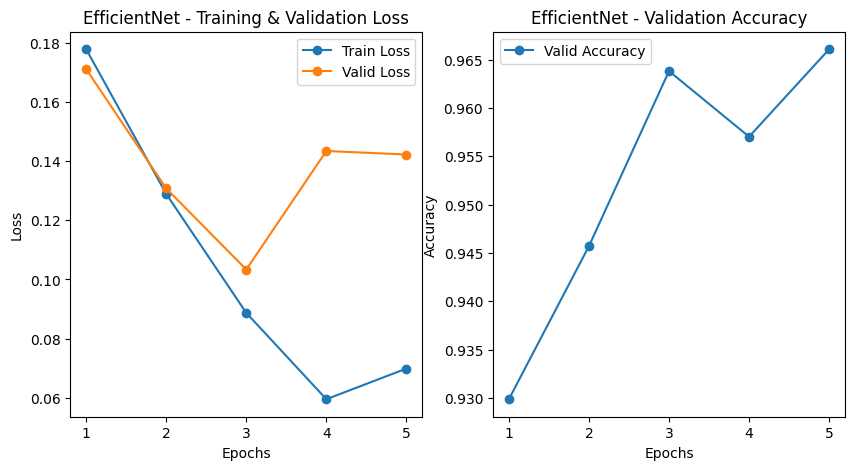

In [50]:
epochs = [1,2,3,4,5]

true_valid_losses = ef_valid_losses[0::2]
true_valid_accuracy = ef_valid_losses[1::2]

plt.figure(figsize=(10,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(epochs, ef_train_losses, label="Train Loss", marker='o')
plt.plot(epochs, true_valid_losses, label="Valid Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("EfficientNet - Training & Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(epochs, true_valid_accuracy, label="Valid Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("EfficientNet - Validation Accuracy")
plt.legend()

plt.show()